In [4]:
import pandas as pd
import numpy as np
import helper
import project1
import importlib

# n_jobs=1 will reload our code
X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)
metrics = ["accuracy", "precision", "f1_score", "auroc", "average_precision", 
            "sensitivity", "specificity"]

Loading training_subset data: 100%|██████████| 2000/2000 [00:03<00:00, 536.53it/s]

Loaded n = 2000 feature vectors


### QUESTION 1 ###

In [5]:
# 1D

means = np.nanmean(X_train, axis=0)
q1    = np.nanpercentile(X_train, 25, axis=0)
q3    = np.nanpercentile(X_train, 75, axis=0)
iqr   = q3 - q1

summary_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Value": np.round(means, 4),
    "Interquartile Range": np.round(iqr, 4),
})

summary_df = summary_df.sort_values("Feature").reset_index(drop=True)
print(summary_df.to_string(index=False))

        Feature  Mean Value  Interquartile Range
            Age      0.6471               0.3378
         Gender      0.5790               1.0000
         Height      0.3722               0.0008
        ICUType      0.5933               0.6667
         Weight      0.2950               0.1136
        max_ALP      0.0717               0.0165
        max_ALT      0.0156               0.0137
        max_AST      0.0157               0.0138
    max_Albumin      0.5053               0.0000
        max_BUN      0.1319               0.0979
  max_Bilirubin      0.0430               0.0252
max_Cholesterol      0.3261               0.0000
 max_Creatinine      0.0649               0.0334
    max_DiasABP      0.3330               0.0394
       max_FiO2      0.7504               0.4167
        max_GCS      0.8772               0.2500
    max_Glucose      0.1389               0.0684
       max_HCO3      0.3503               0.1389
        max_HCT      0.3335               0.1459
         max_HR     

### QUESTION 2 ###

In [6]:
# 2C

C_range = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
penalties = ["l1", "l2"]

results = []
for m in metrics:
    
    best_C, best_penalty = project1.select_param_logreg(X_train, y_train, C_range, penalties=penalties, metric=m)

    clf = project1.get_classifier(loss='logistic', penalty=best_penalty, C=best_C)

    # no bootstrapping, cv does fitting for us
    mean_cv, min_cv, max_cv = project1.cv_performance(clf, X_train, y_train, metric=m)

    results.append({
            "Performance Measure": m,
            "C": best_C,
            "Penalty": best_penalty,
            "Mean (Min, Max) CV Performance": f"{mean_cv:.4f} ({min_cv:.4f}, {max_cv:.4f})",
        })

df = pd.DataFrame(results)
print(df.to_string(index=False))

Performance Measure     C Penalty Mean (Min, Max) CV Performance
           accuracy 0.100      l1        0.8606 (0.8594, 0.8625)
          precision 1.000      l2        0.6024 (0.1667, 1.0000)
           f1_score 0.001      l1        0.2456 (0.2418, 0.2466)
              auroc 1.000      l2        0.7804 (0.7539, 0.8192)
  average_precision 1.000      l2        0.3923 (0.2893, 0.4965)
        sensitivity 0.001      l1        1.0000 (1.0000, 1.0000)
        specificity 0.001      l2        1.0000 (1.0000, 1.0000)


In [7]:
# 2D

best_C = 1.0
best_penalty = "l2"

results = []
for m in metrics:
    clf = project1.get_classifier(loss='logistic', penalty=best_penalty, C=best_C)
    clf.fit(X_train, y_train)

    # bootstrap arg
    median, lo, hi = project1.performance(clf, X_test, y_test, metric=m, bootstrap=True)
    results.append({
            "Performance Measure": m,
            "Median": round(median, 4),
            "95% Confidence Interval": f"({lo:.4f}, {hi:.4f})"
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

Performance Measure  Median 95% Confidence Interval
           accuracy  0.8575        (0.8200, 0.8875)
          precision  0.4167        (0.1429, 0.7273)
           f1_score  0.1449        (0.0351, 0.2623)
              auroc  0.7832        (0.7272, 0.8348)
  average_precision  0.3586        (0.2472, 0.4760)
        sensitivity  0.0877        (0.0200, 0.1703)
        specificity  0.9798        (0.9645, 0.9942)


In [8]:
# 2E

C_range = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
penalties = ["l1", "l2"]

project1.plot_weight(X_train, y_train, C_range, penalties)

Plotting the number of nonzero entries of the parameter vector as a function of C


In [9]:
# 2F

clf = project1.get_classifier(loss='logistic', penalty='l1', C=1.0)
clf.fit(X_train, y_train)

w = clf.coef_.ravel()

pos_idx = np.argsort(w)[-4:] # top 4 ASC
neg_idx = np.argsort(w)[:4]  # 4 ASC

pos_rows = [(round(float(w[i]), 4), feature_names[i]) for i in pos_idx[::-1]] # reverse our pos_idx to be DESC
neg_rows = [(round(float(w[i]), 4), feature_names[i]) for i in neg_idx]


pos_df = pd.DataFrame(pos_rows, columns=["Positive Coefficient", "Feature Name"])
print(pos_df.to_string(index=False))


neg_df = pd.DataFrame(neg_rows, columns=["Negative Coefficient", "Feature Name"])
print(neg_df.to_string(index=False))

 Positive Coefficient  Feature Name
               4.1053 max_Bilirubin
               2.5931       max_BUN
               1.6193        max_HR
               1.5566           Age
 Negative Coefficient Feature Name
              -2.7041      max_GCS
              -2.0179    max_Urine
              -0.9237     max_SaO2
              -0.8589     max_HCO3


### QUESTION 3 ###

In [10]:
# 3.2 B

class_weights = {-1: 1, 1: 50}

clf = project1.get_classifier(
    loss="logistic",
    penalty="l2",
    C=1.0,
    class_weight=class_weights
)

clf.fit(X_train, y_train)

metrics = ["accuracy", "precision", "f1_score", "auroc", 
           "average_precision", "sensitivity", "specificity"]

results = []

for metric in metrics:
    median, lo, hi = project1.performance(clf, X_test, y_test, metric=metric, bootstrap=True)
    results.append({
        "Performance Measure": metric,
        "Median": round(median, 4),
        "95% Confidence Interval": f"({lo:.4f}, {hi:.4f})"
    })

table5_df = pd.DataFrame(results)
print(table5_df.to_string(index=False))

Performance Measure  Median 95% Confidence Interval
           accuracy  0.2375        (0.1975, 0.2825)
          precision  0.1538        (0.1178, 0.1931)
           f1_score  0.2667        (0.2107, 0.3237)
              auroc  0.7412        (0.6780, 0.7976)
  average_precision  0.3490        (0.2370, 0.4606)
        sensitivity  1.0000        (1.0000, 1.0000)
        specificity  0.1158        (0.0833, 0.1522)


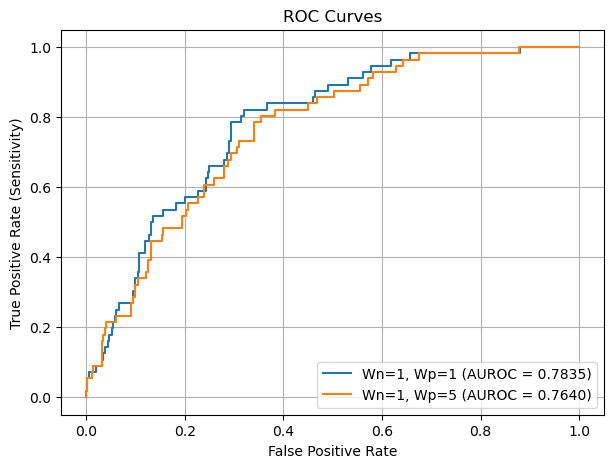

In [11]:
# 3.3 A

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# create and fit W_n = 1, W_p = 1
clf_balanced = project1.get_classifier(
    loss="logistic",
    penalty="l2",
    C=1.0,
    class_weight={-1: 1, 1: 1},
)
clf_balanced.fit(X_train, y_train)
scores_balanced = clf_balanced.decision_function(X_test)
fpr_bal, tpr_bal, _ = roc_curve(y_test, scores_balanced, pos_label=1)
roc_auc_bal = auc(fpr_bal, tpr_bal)



# create and fit W_n = 1, W_p = 5
clf_weighted = project1.get_classifier(
    loss="logistic",
    penalty="l2",
    C=1.0,
    class_weight={-1: 1, 1: 5},
)
clf_weighted.fit(X_train, y_train)
scores_weighted = clf_weighted.decision_function(X_test)
fpr_w, tpr_w, _ = roc_curve(y_test, scores_weighted, pos_label=1)
roc_auc_w = auc(fpr_w, tpr_w)



# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_bal, tpr_bal, label=f"Wn=1, Wp=1 (AUROC = {roc_auc_bal:.4f})")
plt.plot(fpr_w, tpr_w, label=f"Wn=1, Wp=5 (AUROC = {roc_auc_w:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### QUESTION 4 ###

In [12]:
# 4.1 B

clf = project1.get_classifier(loss='logistic', penalty='l2', C=1.0)
clf.fit(X_train, y_train)
clf_results = []


kernel = project1.get_classifier(loss='squared_error', C=1.0, kernel='linear')
kernel.fit(X_train, y_train)
kernel_results = []

for metric in metrics:
    clf_median, clf_lo, clf_hi = project1.performance(clf, X_test, y_test, metric=metric, bootstrap=True)
    clf_results.append({
        "Metric": metric,
        "Median": round(clf_median, 4),
        "95% Confidence Interval": f"({clf_lo:.4f}, {clf_hi:.4f})"
    })

    kernel_median, kernel_lo, kernel_hi = project1.performance(kernel, X_test, y_test, metric=metric, bootstrap=True)
    kernel_results.append({
        "Metric": metric,
        "Median": round(kernel_median, 4),
        "95% Confidence Interval": f"({kernel_lo:.4f}, {kernel_hi:.4f})"
    })


t1 = pd.DataFrame(clf_results)
print("-------------------------- Logistic --------------------------")
print(t1.to_string(index=False))


t2 = pd.DataFrame(kernel_results)
print("\n-------------------------- Ridge --------------------------")
print(t2.to_string(index=False))

-------------------------- Logistic --------------------------
           Metric  Median 95% Confidence Interval
         accuracy  0.8575        (0.8200, 0.8875)
        precision  0.4167        (0.1429, 0.7273)
         f1_score  0.1449        (0.0351, 0.2623)
            auroc  0.7832        (0.7272, 0.8348)
average_precision  0.3586        (0.2472, 0.4760)
      sensitivity  0.0877        (0.0200, 0.1703)
      specificity  0.9798        (0.9645, 0.9942)

-------------------------- Ridge --------------------------
           Metric  Median 95% Confidence Interval
         accuracy  0.8700        (0.8350, 0.9000)
        precision  0.7303        (0.3333, 1.0000)
         f1_score  0.1562        (0.0384, 0.2857)
            auroc  0.7600        (0.6985, 0.8181)
average_precision  0.3463        (0.2361, 0.4541)
      sensitivity  0.0877        (0.0200, 0.1703)
      specificity  0.9943        (0.9853, 1.0000)


In [13]:
# 4.2 B

gammas = [0.001, 0.01, 0.1, 1, 10, 100]

result = []
for gamma in gammas:
    kernel = project1.get_classifier(loss="squared_error", C=1.0, kernel="rbf", gamma=gamma)
    mean_score, min_score, max_score = project1.cv_performance(kernel, X_train, y_train, metric='auroc')

    result.append({
        'Gamma': gamma,
        'Mean (Min, Max) CV Performance': f"{mean_score:.4f} ({min_score:.4f}, {max_score:.4f})"
    })

table = pd.DataFrame(result)
print(table.to_string(index=False))


  Gamma Mean (Min, Max) CV Performance
  0.001        0.7467 (0.6949, 0.8029)
  0.010        0.7748 (0.7405, 0.8089)
  0.100        0.7915 (0.7589, 0.8248)
  1.000        0.7675 (0.7253, 0.7854)
 10.000        0.7485 (0.7194, 0.7840)
100.000        0.7164 (0.6744, 0.7605)


In [14]:
# 4.2 C

gamma_set = [0.01, 0.1, 1.0, 10.0]
C_set = [0.01, 0.1, 1.0, 10, 100]

best_C, best_gamma = project1.select_param_RBF(X_train, y_train, C_set, gamma_set, metric="auroc")

print(f"Best C: {best_C}, Best Gamma: {best_gamma}\n")

kernel = project1.get_classifier(loss='squared_error', C=best_C, kernel='rbf', gamma=best_gamma)
kernel.fit(X_train, y_train)


results = []
for metric in metrics:
    median, lo, hi = project1.performance(kernel, X_test, y_test, metric=metric, bootstrap=True)
    results.append({
        "Metric": metric,
        "Median": round(median, 4),
        "95% Confidence Interval": f"({lo:.4f}, {hi:.4f})"
    })


result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

Best C: 1.0, Best Gamma: 0.1

           Metric  Median 95% Confidence Interval
         accuracy  0.8700        (0.8350, 0.9000)
        precision  0.7303        (0.3333, 1.0000)
         f1_score  0.1562        (0.0384, 0.2857)
            auroc  0.7842        (0.7252, 0.8387)
average_precision  0.3676        (0.2530, 0.4821)
      sensitivity  0.0877        (0.0200, 0.1703)
      specificity  0.9943        (0.9853, 1.0000)


### QUESTION 5 - CHALLENGE ###

In [15]:
from copy import deepcopy
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

X_train_full, y_train_full, X_challenge, feature_names = helper.get_challenge_data()

Loading training_full data:   1%|          | 100/10000 [00:02<02:14, 73.62it/s]/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:457: RuntimeWarning: All-NaN slice encountered
  "min": float(np.nanmin(values)),
/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:458: RuntimeWarning: Mean of empty slice
  "mean": float(np.nanmean(values)),
/Users/lukemcguinness/miniconda3/envs/445_p1/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Loading training_full data:   4%|▍         | 420/10000 [00:03<00:35, 269.68it/s]/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:457: RuntimeWarning: All-NaN slice encountered
  "min": float(np.nanmin(values)),
/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:458: RuntimeWarning: Mean of empty slice
  "mean": float(np.nanmean(values)),
/Users/lukemcgui

Loaded n = 10000 feature vectors


Loading challenge data:  11%|█         | 220/2000 [00:00<00:04, 424.33it/s]/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:457: RuntimeWarning: All-NaN slice encountered
  "min": float(np.nanmin(values)),
/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:458: RuntimeWarning: Mean of empty slice
  "mean": float(np.nanmean(values)),
/Users/lukemcguinness/miniconda3/envs/445_p1/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Loading challenge data:  27%|██▋       | 540/2000 [00:01<00:04, 292.65it/s]/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:457: RuntimeWarning: All-NaN slice encountered
  "min": float(np.nanmin(values)),
/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/project1.py:458: RuntimeWarning: Mean of empty slice
  "mean": float(np.nanmean(values)),
/Users/lukemcguinness/min

Loaded n = 2000 feature vectors


In [16]:
X_train_c, X_validate_c, y_train_c, y_validate_c = train_test_split(X_train_full, y_train_full, test_size=0.10, stratify=y_train_full, random_state=42)

print(f"Train (CV) size: {X_train_c.shape[0]} | Val size: {X_validate_c.shape[0]} | Challenge size: {X_challenge.shape[0]}")

metrics_c = ["f1_score", "auroc", "accuracy", "precision", "average_precision", 
            "sensitivity", "specificity"]

Train (CV) size: 9000 | Val size: 1000 | Challenge size: 2000


In [17]:
base_lr = LogisticRegression(
    fit_intercept=False,
    max_iter=5000, # increase to 5k so it converges
    random_state=42
)

C_range = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]

class_weights = [
    None,
    "balanced",
    {-1: 1, 1: 2},
    {-1: 1, 1: 5},
    {-1: 1, 1: 10},
]

# from "1.1.11.3. Solvers" GridSearchCV on all acceptable combos
param_grids = [
    # l1 can be liblinear or saga
    {"penalty": ["l1"], "solver": ["liblinear", "saga"], "C": C_range, "class_weight": class_weights},

    # l2 can be lbfgs, liblinear, newton-cg, newton-cholesky, sag, or saga
    {"penalty": ["l2"], "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"], "C": C_range, "class_weight": class_weights},

    # elasticnet can be saga with l1_ratio
    {"penalty": ["elasticnet"], "solver": ["saga"], "l1_ratio": [0.1, 0.5, 0.9], "C": C_range, "class_weight": class_weights},
]

# focus on f1_score for optimization
f1_pos1 = make_scorer(f1_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=False)

gs = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grids,
    scoring={"f1": f1_pos1, "auroc": "roc_auc"},
    refit="f1",
    cv=cv,
    error_score="raise",
)

gs.fit(X_train_c, y_train_c)


# F1 optimized params and F1/AUROC scores
print("Best F1 params:", gs.best_params_)
print("Best F1 (mean CV F1):", gs.cv_results_["mean_test_f1"][gs.best_index_])
print("Best F1 (mean CV AUROC):", gs.cv_results_["mean_test_auroc"][gs.best_index_])


# AUROC optimized params and F1/AUROC scores
cv_res = pd.DataFrame(gs.cv_results_)
idx_auc = cv_res["mean_test_auroc"].idxmax()
best_params_auc = cv_res.loc[idx_auc, "params"]
best_auc = cv_res.loc[idx_auc, "mean_test_auroc"]
best_auc_f1 = cv_res.loc[idx_auc, "mean_test_f1"]

print("\nBest AUROC params:", best_params_auc)
print("Best AUROC (mean CV AUROC):", best_auc)
print("Best AUROC (mean CV F1):", best_auc_f1)

Output:

Best-by-F1 params: {'C': 10, 'class_weight': {-1: 1, 1: 5}, 'penalty': 'l1', 'solver': 'liblinear'}
Best-by-F1 (mean CV F1): 0.46902330120091584
Best-by-F1 (mean CV AUROC): 0.8060025105557458

Best-by-AUROC params: {'C': 1, 'class_weight': {-1: 1, 1: 2}, 'penalty': 'l1', 'solver': 'saga'}
Best-by-AUROC (mean CV AUROC): 0.807379036859523
Best-by-AUROC (mean CV F1): 0.41960536945245097

We will continue forward with C=10, class_weight={-1: 1, 1: 5}, penalty='l1', solver='liblinear'

In [18]:
challenge_clf = project1.get_classifier(loss='logistic', penalty='l1', C=10, class_weight={-1: 1, 1: 5}) # deafult is liblinear
challenge_clf.fit(X_train_c, y_train_c)

for m in metrics_c:
    med, lo, hi = project1.performance(challenge_clf, X_validate_c, y_validate_c, metric=m, bootstrap=True)
    print(f"{m}: {med:.4f}  ({lo:.4f}, {hi:.4f})")

f1_score: 0.5195  (0.4626, 0.5760)
auroc: 0.8432  (0.8092, 0.8748)
accuracy: 0.7980  (0.7720, 0.8230)
precision: 0.4074  (0.3500, 0.4662)
average_precision: 0.5007  (0.4152, 0.5834)
sensitivity: 0.7177  (0.6490, 0.7862)
specificity: 0.8119  (0.7848, 0.8385)


Validation AUROC: 0.8427


/var/folders/sk/57wc0kxd0bld0mny_6rdm1g80000gn/T/ipykernel_36838/3304707796.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


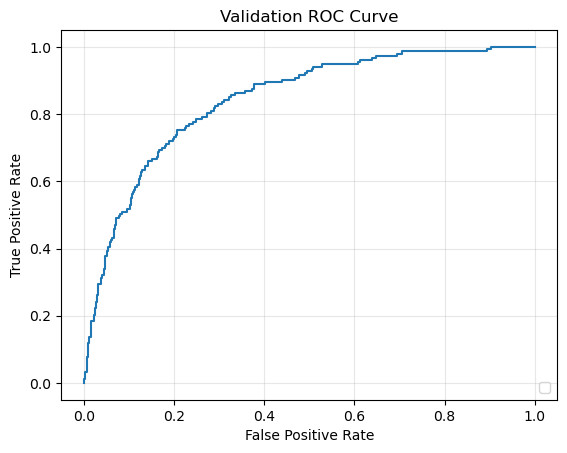

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, confusion_matrix

pred = None
if hasattr(challenge_clf, "decision_function"):
    pred = challenge_clf.decision_function(X_validate_c)
else:
    y = challenge_clf.predict(X_validate_c)
    pred = y.astype(float)


fpr, tpr, thresh = roc_curve(y_validate_c, pred, pos_label=1)
val_auroc = roc_auc_score(y_validate_c, pred)
print(f"Validation AUROC: {val_auroc:.4f}")

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


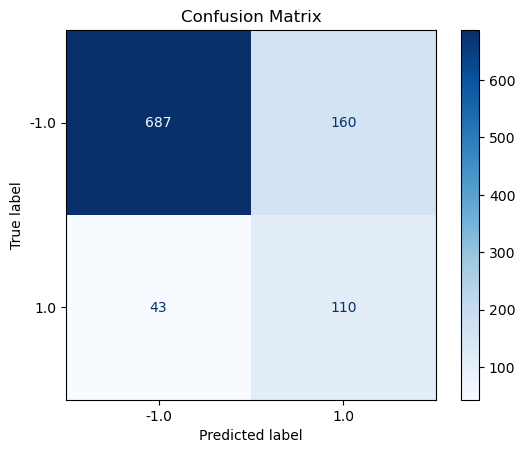

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_pred = challenge_clf.predict(X_validate_c)

cm = confusion_matrix(y_validate_c, cm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=challenge_clf.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.savefig("CM.png")
plt.show()


In [20]:
# fit on full dataset to maximize results
full_clf = project1.get_classifier(loss='logistic', penalty='l1', C=10, class_weight={-1: 1, 1: 5})
full_clf.fit(X_train_full, y_train_full)


final_pred = None
if hasattr(full_clf, "decision_function"):
    final_pred = full_clf.decision_function(X_challenge)
else:
    y = full_clf.predict(X_challenge)
    final_pred = y.astype(float)

final_pred_label = np.where(final_pred >= 0.0, 1, -1)

# sanity check haha
print(final_pred.shape)
print(X_challenge.shape)

(2000,)
(2000, 425)


In [21]:
helper.save_challenge_predictions(
    y_label=final_pred_label,
    y_score=final_pred,
    uniqname="lukemcg"
)